In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [128]:
def Data_Parser(minute, id):
    data = []
    for i in range(1, 4):
        j = i - 1
        data.append(pd.read_csv(f'./results/{minute:02d}/{id:02d}_{i}.csv', index_col = 0).T.reset_index())
        data[j]['class'] = data[j]['class'].astype(int)
        data[j]['speed'] = data[j]['speed'].astype(float)
    data.append(data[0])
    data[3] = pd.concat([data[3], data[1], data[2]], axis = 0, ignore_index = True)
    data[3] = data[3].iloc[:,1:].reset_index()
    return data

In [161]:
order = {0: 'First', 1: 'Second', 2: 'Third', 3: 'Total'}

def One_People_Result(minute, id):
    data = Data_Parser(minute, id)
    fig, axes = plt.subplots(4, 1, figsize = (12, 18))
    
    for i in range(4):
        ax = axes[i]
    
        # 평균 계산
        mean = np.round(data[i]['speed'].mean(), 4) #소숫점 4자리까지 반올림
        ax.axhline(mean, color = 'gray', linestyle = 'dotted', label = '[ Mean ]')
        ax.text(0, 2.3, f'Maen of Speed = {mean} second per unit', fontsize = 13)
    
        # 모든 데이터 시각화
        ax.plot(data[i]['index'], data[i]['speed'], color = 'blue', label = '[ Correct ]', alpha = 0.3)
    
        # 틀린 데이터 시각화 - 빨간 
        w = 3 if i == 3 else 1
        class_data_wrong = data[i][data[i]['class'] == 0]
        ax.text(0, 2.15, f'Number of Wrong Answer = {len(class_data_wrong)}', fontsize = 13)
        ax.bar(class_data_wrong['index'], class_data_wrong['speed'], color = 'red', width = w)
        ax.scatter(class_data_wrong['index'], class_data_wrong['speed'], color = 'red', label = '[ Wrong ]', marker = 'o')
    
        
        ax.set_ylim(0, 2.5)
        if i < 3:
            ax.set_xticks(np.arange(0, 600, 100))
        else:
            ax.set_xticks(np.arange(0, 1800, 100))
    
        ax.set_xlabel('Index')
        ax.set_ylabel('Speed')
        ax.set_title(f'{order[i]} Trial', fontsize = 20)
        ax.legend(title = 'Class', loc = 'upper right')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace = 0.4)
    
    plt.savefig(f'./Graphs/Order by ID/{id:02d}.png', dpi = 200, facecolor = 'lavender')

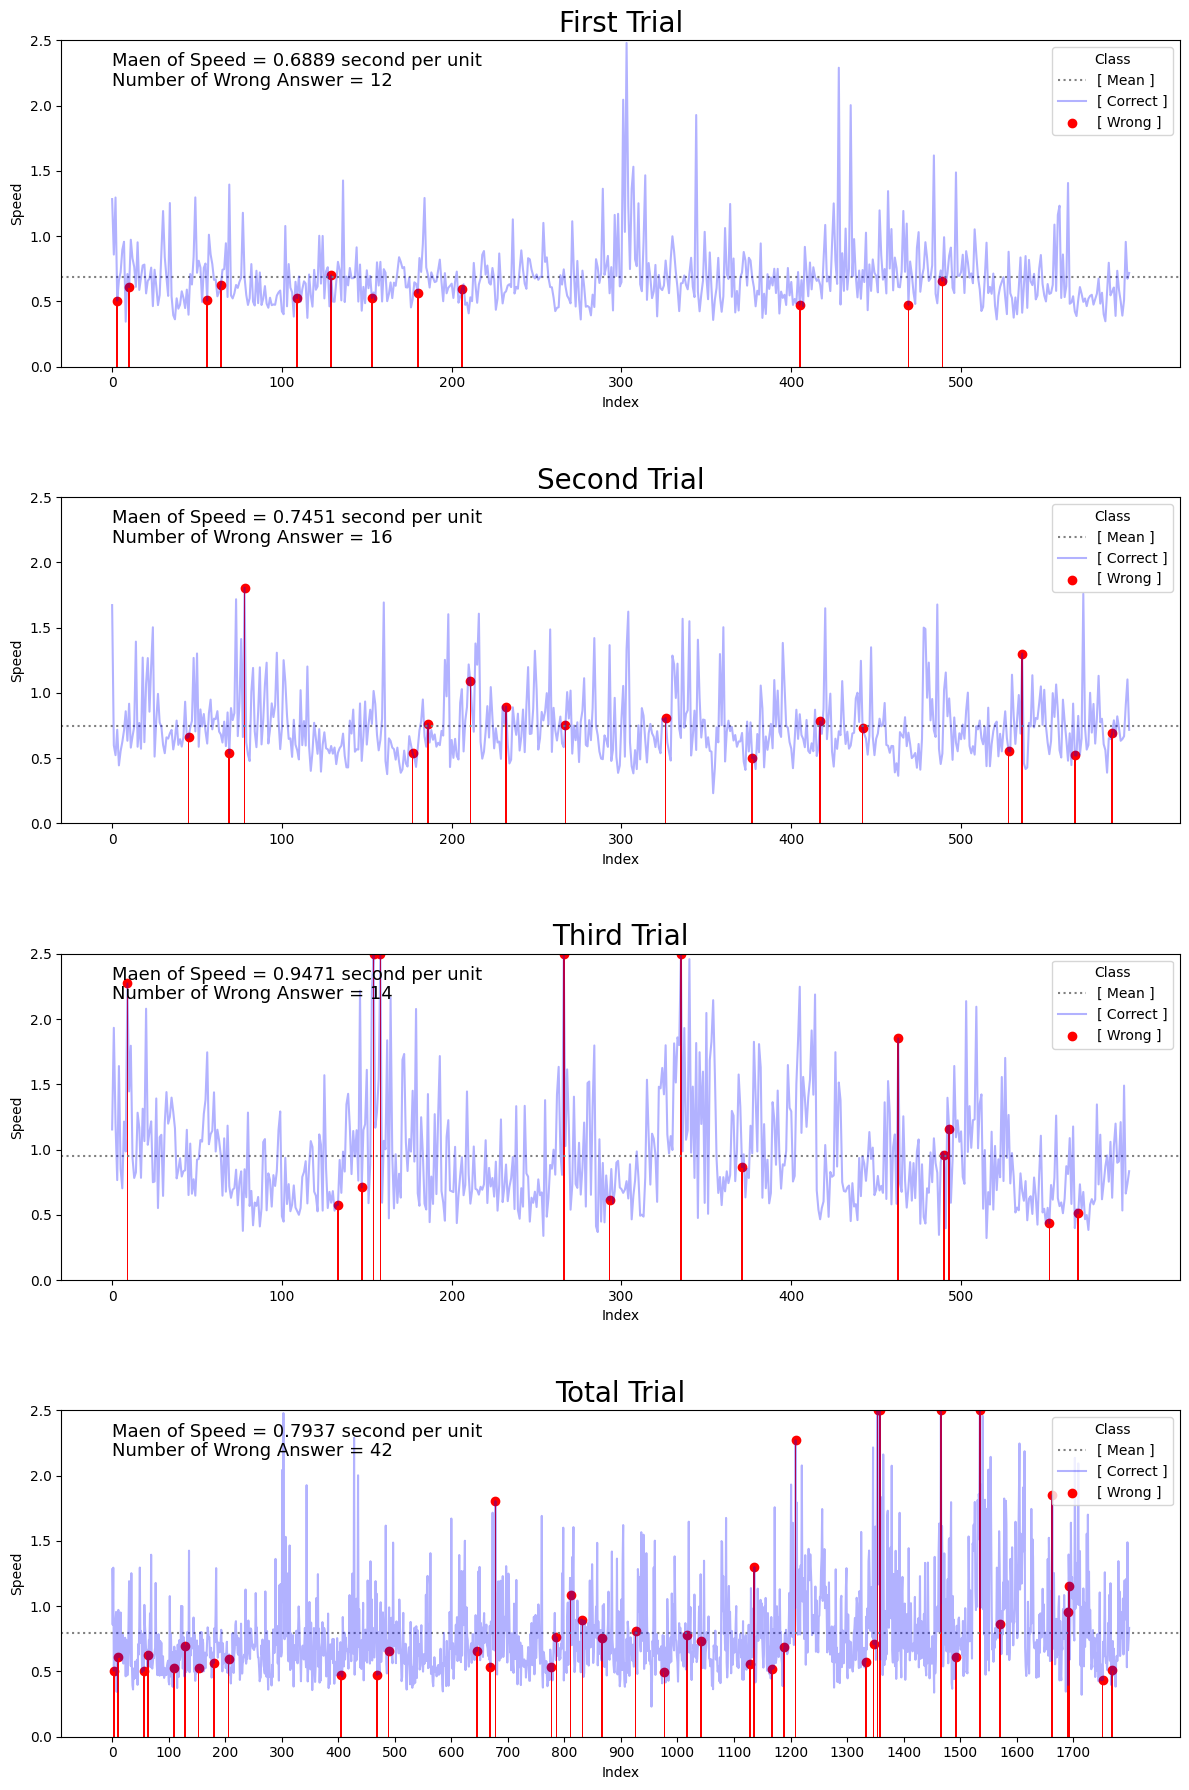

In [160]:
One_People_Result(10,4)

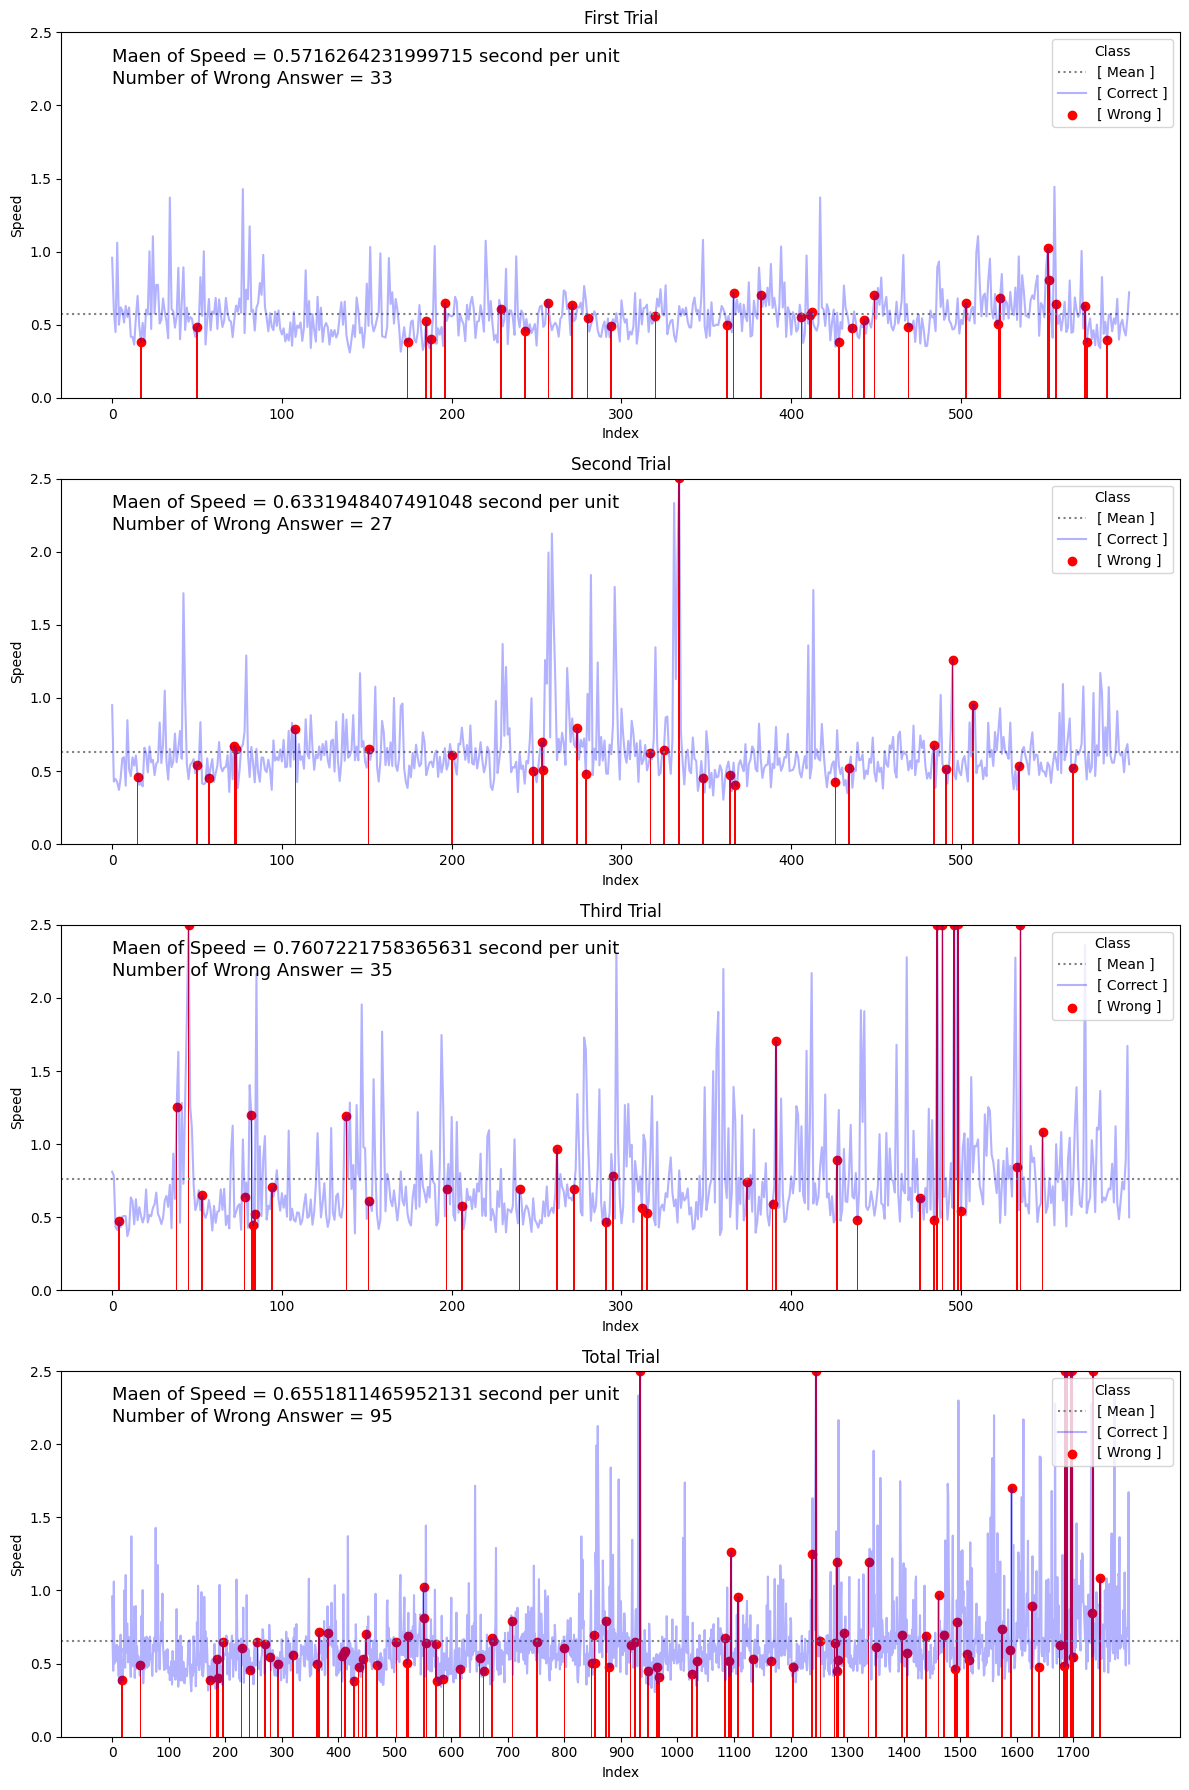

In [133]:
One_People_Result(5, 6)

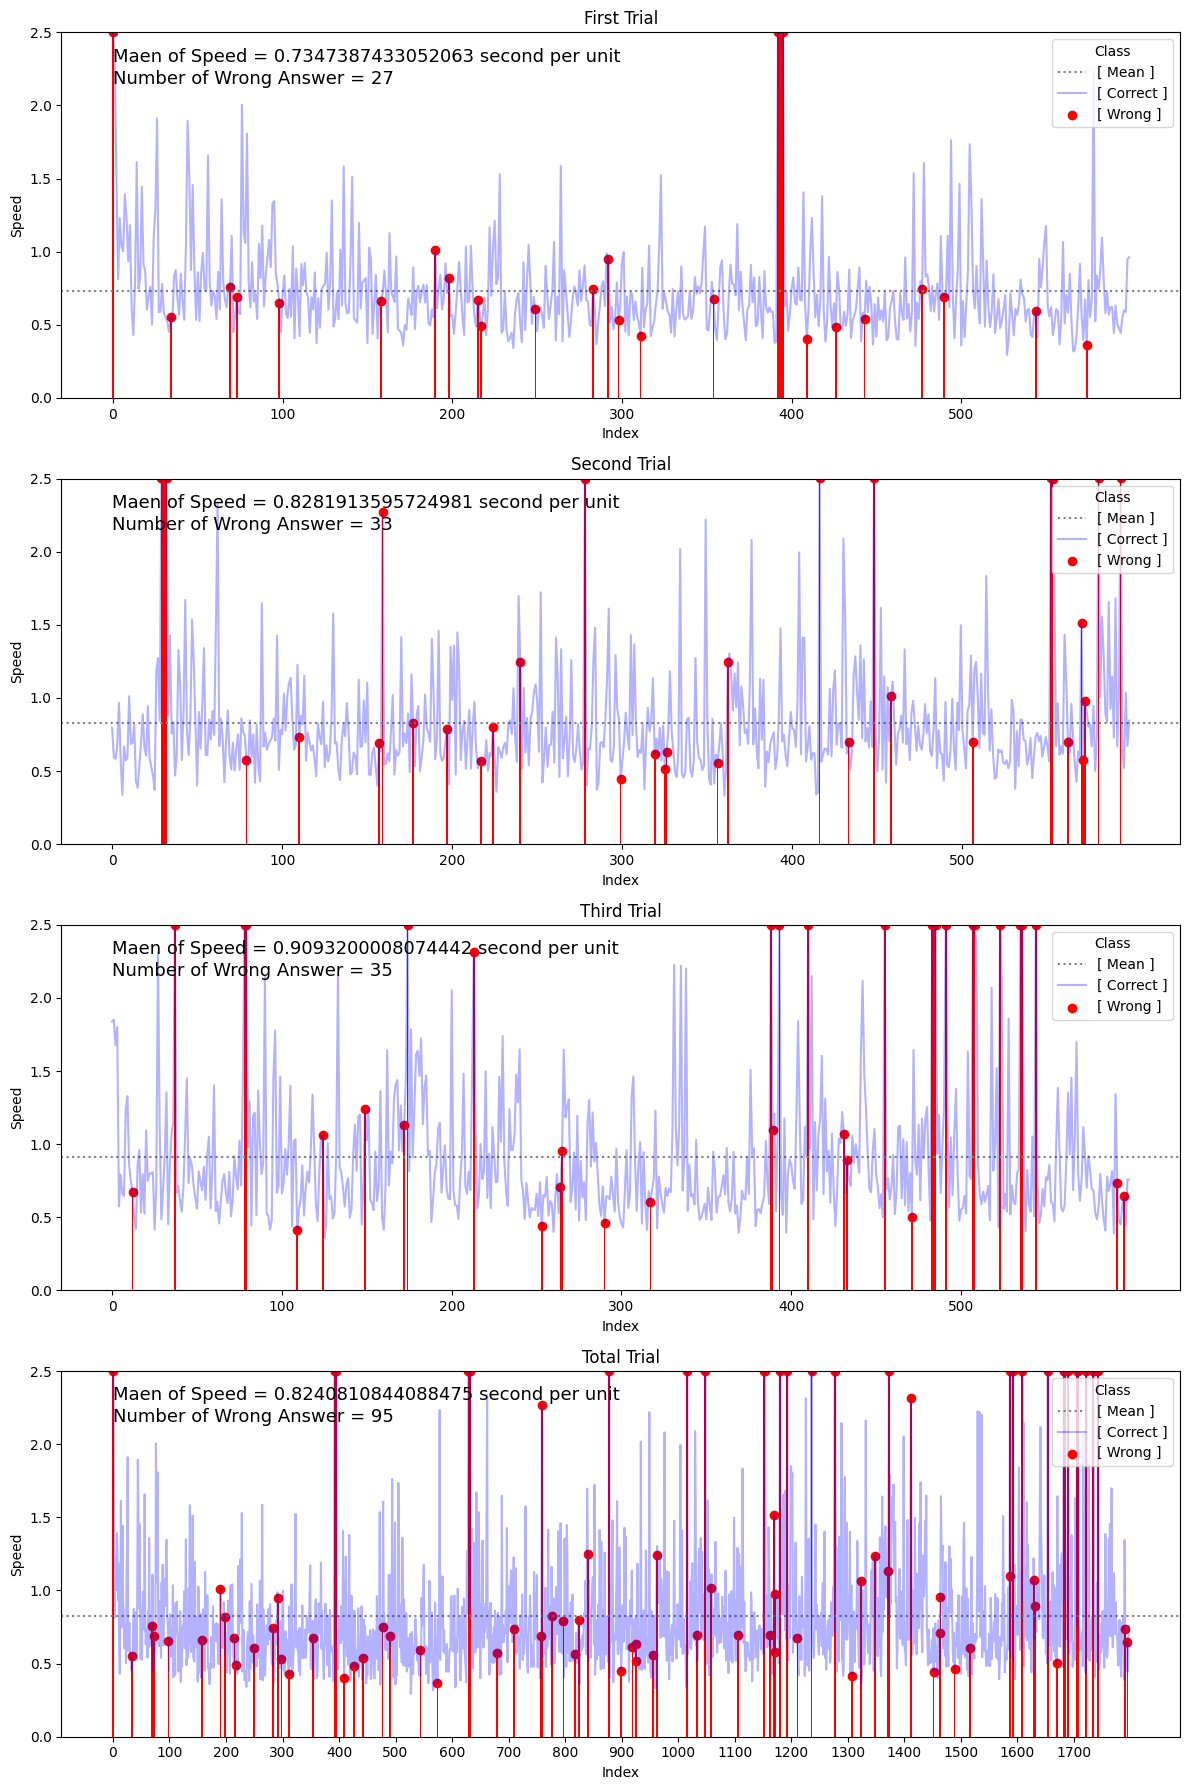

In [134]:
One_People_Result(0, 2)